# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [27]:
STUDENT_NAME = "QUACH VO HOANG HUY"  # TODO: Họ và tên
STUDENT_ID = "2411267"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: QUACH VO HOANG HUY (2411267)


In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /workspaces/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [29]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [30]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities,axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [31]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [32]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [33]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...
train_feature_mean = np.mean(X_train,axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled =(X_train - train_feature_mean)/train_feature_std
X_val_scaled = (X_val- train_feature_mean)/ train_feature_std


In [34]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [35]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [36]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...
correct_mask = true_labels == predicted_classes
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = ~correct_mask & high_confidence_mask
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [37]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [38]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Kí hiệu missing value trong CSV là thể hiện cho giá trị bị khuyết trong quá trình thu thập dữ liệu.
3. `symboling` có ý nghĩa là Mức đánh giá rủi ro bảo hiểm.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [39]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...
raw_df = pd.read_csv(r"data/automobile_raw.csv")
raw_shape = raw_df.shape
raw_missing_marker_count = raw_df.isin(['?']).sum()
print(" Raw data shape:", raw_shape)

 Raw data shape: (205, 26)


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [40]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [41]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
df_clean=raw_df.copy()
df_clean = df_clean.replace("?",np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column]= pd.to_numeric(df_clean[column])
missing_by_column= pd.DataFrame(df_clean.isna().sum(), columns=['Missing_Count'])
display(missing_by_column)

,Missing_Count
symboling,0
normalized_losses,41
make,0
fuel_type,0
aspiration,0
num_doors,2
body_style,0
drive_wheels,0
engine_location,0
wheel_base,0


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
- Vì mỗi cột thể hiện một đặc trưng riêng và có một phân phối riêng. Nếu điền cùng 1 giá trị sẽ khiến cho dữ liệu mỗi cột bị sai lệch phân phối.
- Đối với dataset này, drop các dòng thiếu của price sẽ phù hợp hơn. Vì price là biến mục tiêu và tổng số missing của price khá ít nên nếu drop đi cũng sẽ không ảnh hưởng đến kết quả huấn luyện. Nếu điền bằng mean hoặc median có thể khiến xảy ra sai lệch
- `normalized_losses` thiếu 41 dữ liệu trên 205 giá trị chiếm 1/5 dữ liệu bảng. Điều này ảnh hưởng lớn đến độ tin cậy của kết quả và nếu điền dữ liệu thiếu thì sẽ làm sai lệch kết quả.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [42]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [43]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...
analysis_df= df_clean[AUTO_FEATURES].copy()
analysis_df= analysis_df.dropna()
X_auto= np.array(analysis_df,dtype="float64")
auto_feature_mean = X_auto.mean()
auto_feature_std= X_auto.std()
X_auto_scaled= (X_auto - auto_feature_mean)/auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [44]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...
price_index = analysis_df.columns.get_loc('price')
price_z= X_auto_scaled[:,price_index]
price_outlier_mask = np.abs(price_z)>2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [45]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...
engine_price_corr = analysis_df["engine_size"].corr(analysis_df["price"])
price_by_body_style = df_clean.groupby("body_style")["price"].mean()
print(engine_price_corr)
print(price_by_body_style)

0.8738869517981518
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

/tmp/ipykernel_3807/1899315564.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


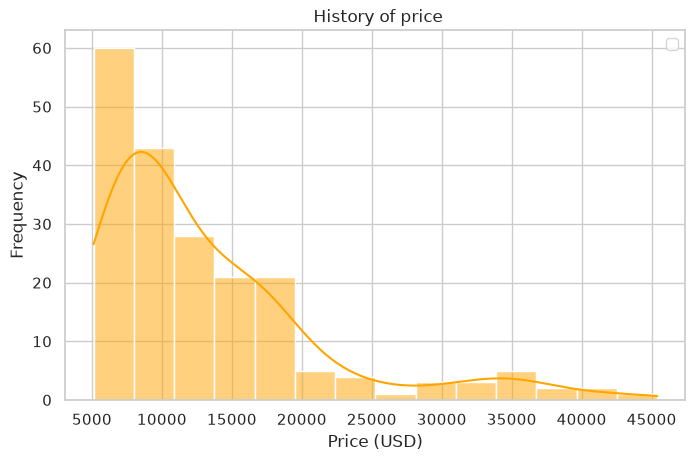

In [46]:
# TODO M2.1: histogram/KDE của price
sns.histplot(analysis_df["price"], kde=True, color="orange" )
plt.title(" History of price")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Price có phân phối lệch phải với phần lớn xe có giá ở mức 5 đến 15 nghìn đô. Xuất hiện 1 số ít xe có giá trị cao tạo thành đuôi kéo dài bên phải.

## M2.2 Dataset có cân bằng theo body style không?

/tmp/ipykernel_3807/3810625247.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


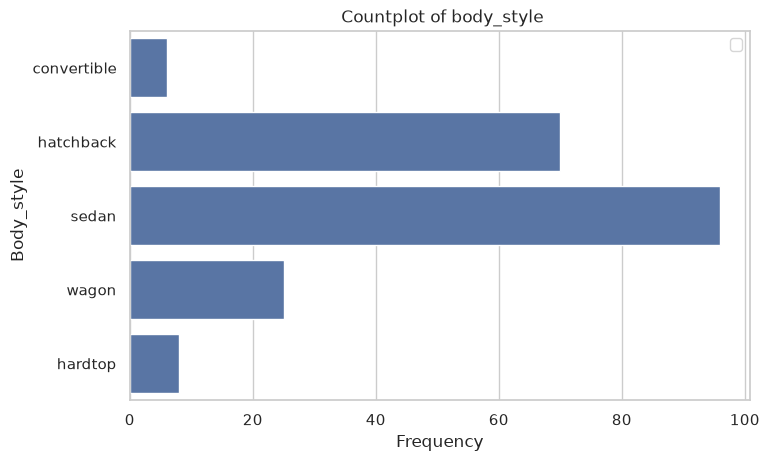

In [47]:
# TODO M2.2: countplot của body_style
sns.countplot(df_clean["body_style"])
plt.title(" Countplot of body_style")
plt.xlabel("Frequency")
plt.ylabel("Body_style")
plt.legend()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Datasheet không cân bằng theo body_style mẫu sedan chiếm tỉ lệ nhiều nhất, tiếp đó là hatchback và wagon. Điều này cho thấy thống kê của sedan sẽ đáng tin cậy hơn vì có nhiều mẫu.

## M2.3 Price khác nhau theo body style ra sao?

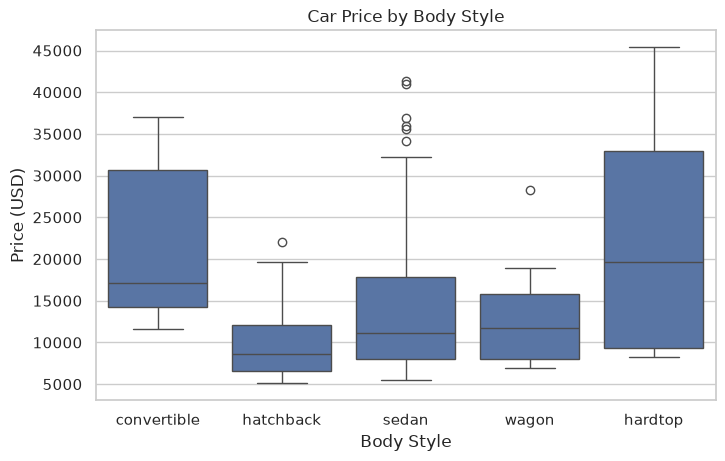

In [48]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x="body_style", y="price")
plt.title("Car Price by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Giá xe khác nhau giữa các kiểu thân xe. Hardtop và convertible có xu hướng có giá trung vị cao hơn, trong khi hatchback có giá thấp nhất; đồng thời xuất hiện giá trị outlayer ở một số nhóm.

## M2.4 Engine size liên quan thế nào tới price?

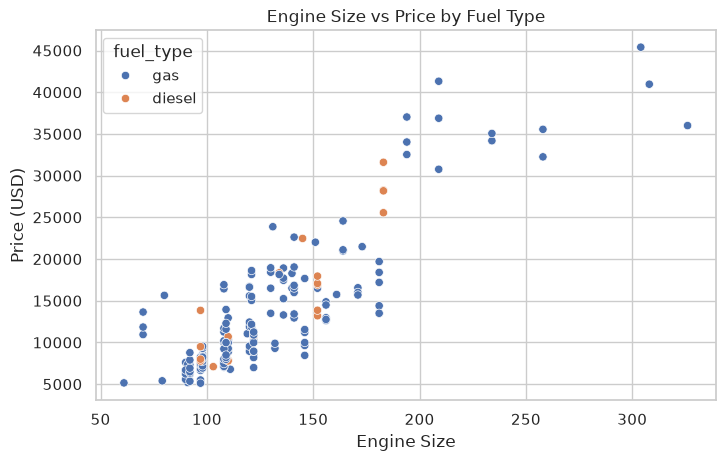

In [49]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(df_clean, x="engine_size", y="price", hue="fuel_type")
plt.title("Engine Size vs Price by Fuel Type")
plt.xlabel("Engine Size")
plt.ylabel("Price (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Giữa price và engine size có mối tương quan dương khá mạnh: xe có động cơ lớn hơn thường có giá cao hơn. Hai nhóm fuel_type (gas và diesel) đều tuân theo xu hướng này.

## M2.5 Các feature numeric tương quan ra sao?

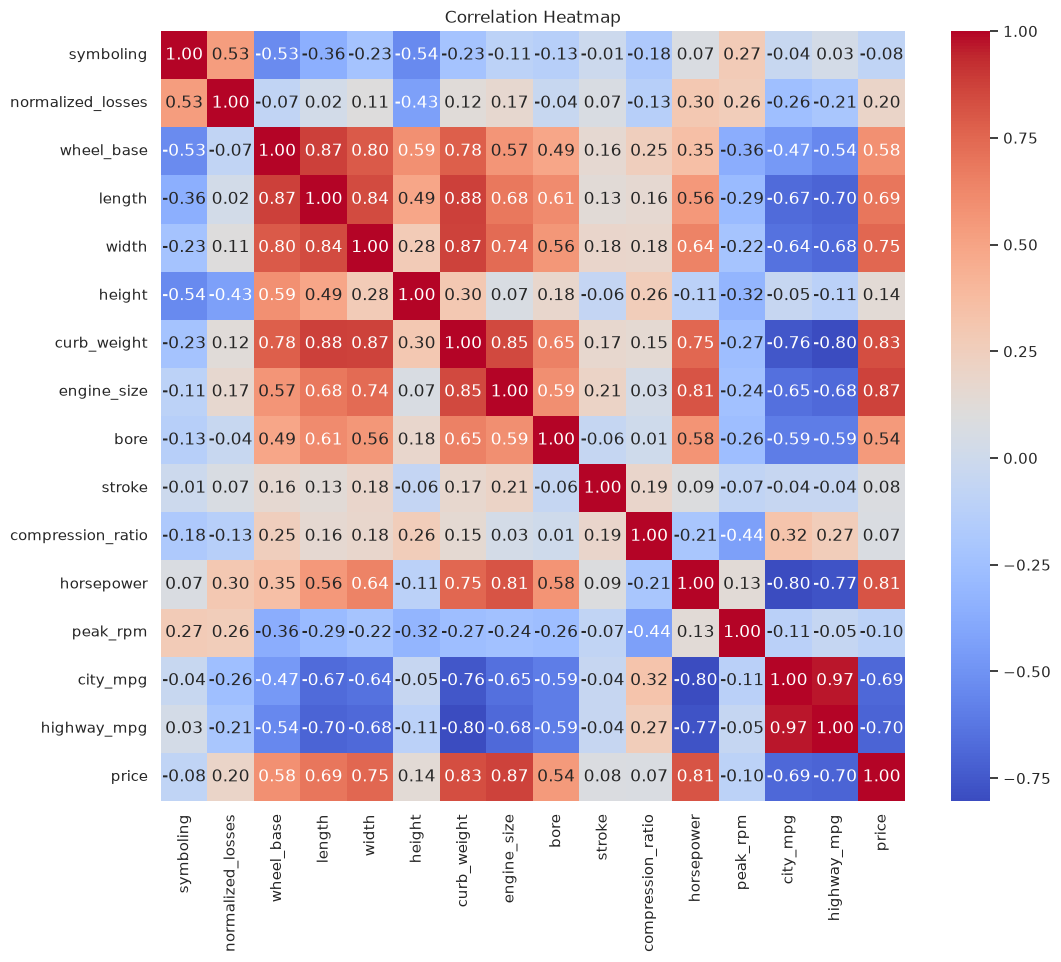

In [50]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean[NUMERIC_COLUMNS].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
- curb_ weight , engine_size và horsepower có tương quan dương khá mạnh với price có thể dùng để dự đoán giá xe 
- highway_rpm và city_rpm có tương quan dương lớn cần lưu ý tránh hiện tưởng cộng đa tuyến.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

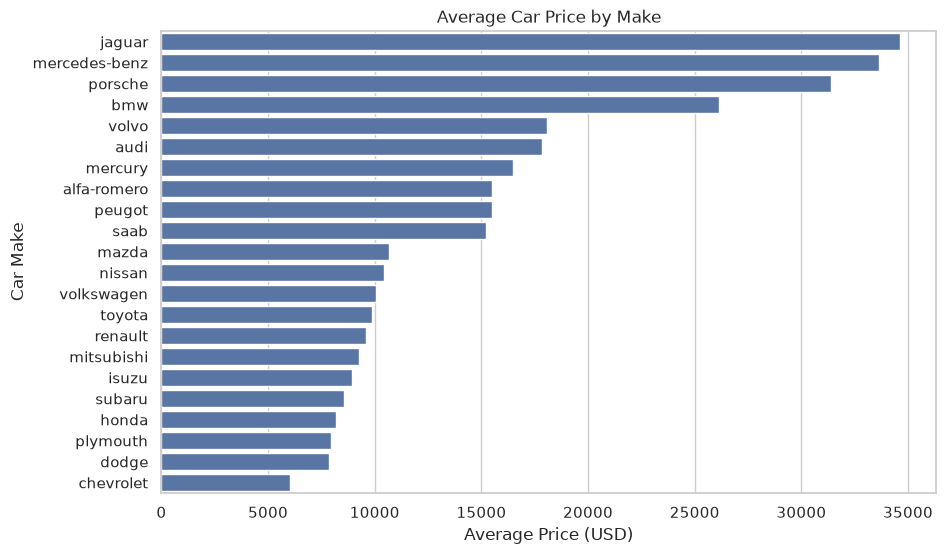

In [51]:
# TODO M2.6: biểu đồ tự chọn
avg_price = df_clean.groupby("make")["price"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price.values, y=avg_price.index)
plt.title("Average Car Price by Make")
plt.xlabel("Average Price (USD)")
plt.ylabel("Car Make")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Giá trung bình khác nhau đáng kể giữa các hãng xe. Một số hãng thuộc phân khúc cao cấp có giá trung bình cao hơn rõ rệt so với các hãng phổ thông.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
Qua quá trình EDA, có thể rút ra một số phát hiện quan trọng về bộ dữ liệu Automobile. Thứ nhất, engine_size có tương quan dương mạnh với price (≈ 0.87), bên cạnh curb_weight (≈ 0.83) và horsepower (≈ 0.81), qua đó ta có thể dựa vào các biến này để dự đoán giá của xe. Thứ hai, price có phân phối lệch phải, phần lớn xe có giá trong khoảng 5.000–15.000 USD, trong khi chỉ một số ít xe có giá rất cao. Thứ ba, dataset không cân bằng theo body_style, với sedan chiếm nhiều mẫu nhất và convertible hoặc hardtop có số lượng khá ít. Cuối cùng giá xe bị ảnh hưởng bởi hãng sản xuất, các hãng càng lớn và lâu đời thì giá xe càng cao (jaguar, mecedes-benz,...). Về hạn chế của datasheet, ở cột normalized_losses thiếu dữ liệu nghiêm trọng chiếm 1/5 dữ liệu của datasheet. Sự mất cân bằng dữ liệu ở một số nhóm, có thể ảnh hưởng đến chất lượng phân tích và mô hình. Bên cạnh đó, cần lưu ý rằng tương quan không đồng nghĩa với quan hệ nhân quả; mặc dù engine_size và price có tương quan cao, điều đó không có nghĩa việc tăng dung tích động cơ sẽ trực tiếp làm tăng giá xe vì giá còn chịu ảnh hưởng của nhiều yếu tố khác như thương hiệu, trang bị và công nghệ.Trong các bước tiếp theo, có thể đánh giá mức độ quan trọng của từng đặc trưng và xem xét xử lý các feature có tương quan quá cao để xây dựng mô hình dự đoán hiệu quả hơn.